## Single-layer perceptron from scratch (no data science libraries)

In [ ]:
# helper for debugging list comprehensions

def print_return(*args):
  print(*args)
  if len(args) == 1:
    return args[0]
  return list(args)

In [ ]:
import math

# math functions
regular_round = lambda x: math.floor(x + 0.5)
sigmoid = lambda x: 1 / (1 + math.exp(-x))
threshold = lambda t: lambda x: 1 if x >= t else 0
def compose(f, g):
  return lambda x: f(g(x))

In [ ]:
# @title Downloading data

import requests
import zipfile
import io
import os

def get_url_content(url):
  response = requests.get(url)
  response.raise_for_status()
  return response.content

def unzip(path_to, zipped_data):
  with zipfile.ZipFile(io.BytesIO(zipped_data), 'r') as zip_ref:
    zip_ref.extractall(path_to)

def download_unzipped_data(path_to, urls):
  os.makedirs(path_to, exist_ok=True)
  for url in urls:
    unzip(path_to, get_url_content(url))


IRIS_DATA_URL = 'https://archive.ics.uci.edu/static/public/53/iris.zip'
BREAST_CANCER_DATA_URL = 'https://archive.ics.uci.edu/static/public/15/breast+cancer+wisconsin+original.zip'
DATA_PATH = 'data'
download_unzipped_data(DATA_PATH, (IRIS_DATA_URL, BREAST_CANCER_DATA_URL))

In [ ]:
# @title Filtering downloaded data

def remove_files(path, keep_keywords, keep_extensions):
  for file_name in os.listdir(path):
      file_name_contains_keyword = \
        any(keyword in file_name for keyword in keep_keywords)
      file_name_contains_extension = \
        any(file_name.endswith(extension) for extension in keep_extensions)
      file_is_unwanted = file_name_contains_keyword and file_name_contains_extension
      if not file_is_unwanted:
        os.remove(os.path.join(path, file_name))

remove_files(DATA_PATH,
            keep_keywords=('iris', 'breast'),
            keep_extensions=('.data'))

def clean_lines(file_path, delete_if, transform_line):
  transformed_lines = ''
  with open(file_path, 'r') as read_file:
    for line in read_file.readlines():
      if not delete_if(line):
        line = transform_line(line)
        transformed_lines += line
  with open(file_path, 'w') as write_file:
    write_file.write(transformed_lines)

def replace(replace_map):
  def replace_string(string):
    for value in replace_map.keys():
      if value in string:
        string = string.replace(value, replace_map[value])
    return string
  return replace_string

def remove_first_element(separator=','):
  return lambda string: string.split(separator, 1)[1]

IRIS_DATA_PATH = f'{DATA_PATH}/iris.data'
CANCER_DATA_PATH = f'{DATA_PATH}/breast-cancer-wisconsin.data'

clean_lines(IRIS_DATA_PATH,
           delete_if=lambda line: 'setosa' in line or '?' in line,
           transform_line=replace({'Iris-versicolor': '0', 'Iris-virginica': '1'}))

clean_lines(CANCER_DATA_PATH,
           delete_if=lambda line: '?' in line,
           transform_line=compose(replace({'2': '0', '4': '1'}), remove_first_element()))

In [ ]:
# @title Data class

class Data:
  def __init__(self, data):
    # data stores tuple of (features, target)
    self.data = data

  @classmethod
  def from_file(self, path, column_count, seperator=','):
    data = []
    with open(path, 'r') as read_file:
      for line in read_file.readlines():
        row = []
        for value in line.split(seperator)[:column_count]:
          try:
            value = float(value)
            row.append(value)
          except ValueError:
            continue
        if len(row) == column_count:
          # seperate target and features
          target = row.pop()
          data.append((row, target))
    return self(data)

  def shuffle(self, seed=271828, epochs=3):
    data_size = len(self)
    for epoch in range(epochs):
      # some formula for generating random number between 0 and data_size
      swap_distance = (seed + epoch) % data_size
      for i in range(data_size):
        swap_i = i + swap_distance
        if swap_i >= data_size:
          # swap_i is out of bounds so wrap around
          swap_i -= data_size
        # swap i and swap_i rows
        self.data[i], self.data[swap_i] = self.data[swap_i], self.data[i]

  def save_to_csv(self, path):
    with open(path, 'w') as write_file:
      for features_target in self.data:
        features = ','.join(map(str, features_target[0]))
        target = str(features_target[1])
        write_file.write(f'{features},{target}\n')

  def split(self, train_percent=0.7):
    self.shuffle()
    train_size = int(train_percent * len(self))
    train_data = self.data[0:train_size]
    test_data = self.data[train_size:]
    return (Data(train_data), Data(test_data))

  def __len__(self):
    return len(self.data)

  def get_bias_features(self):
    return [[1] + features_target[0] for features_target in self.data]

  def get_targets(self):
    return [feature_target[1] for feature_target in self.data]

  def get_data(self):
    return (self.get_bias_features(), self.get_targets())

In [ ]:
# @title Stochastic sigmoid perceptron class

class StochasticSigmoidPerceptron:
  def __init__(self, feature_count):
    # +1 for bias
    self.init_weights(weight_count=feature_count + 1)

  def init_weights(self, weight_count):
    self.weights = [0 for _ in range(weight_count)]

  def reset_weights(self):
    self.init_weights(len(self.weights))

  def get_weights_string(self):
    return '; '.join(('{:.3f}'.format(round(weight, 3)) for weight in self.weights)).replace('.', ',')

  def predict(self, input_with_bias):
    prediction = sigmoid(sum(
        [weight * data for weight, data in zip(self.weights, input_with_bias)]
      ))
    return prediction

  def train(self, data, learning_rate, epochs=10, min_epoch_error=0):
    epochs_errors = []
    epochs_accuracy = []
    for epoch in range(epochs):
      data.shuffle()
      features, targets = data.get_data()
      epoch_error = 0
      guessed_correctly = 0
      for i in range(len(data)):
        prediction = self.predict(features[i])
        # update weights
        for j in range(len(self.weights)):
          self.weights[j] -= \
          learning_rate * (prediction - targets[i]) \
          * prediction * (1 - prediction) * features[i][j]
        epoch_error += (targets[i] - prediction) ** 2
        guessed_correctly += (regular_round(prediction) == targets[i])
      epochs_errors.append(epoch_error)
      epochs_accuracy.append(guessed_correctly / len(data))
      if epoch_error < min_epoch_error:
        print(f'epoch_error < min_epoch_error for learning_rate={learning_rate}, epoch={epoch}')
        break
    return (epochs_errors, epochs_accuracy)

  def test(self, data, threshold_value=0.5):
    bias_features, targets = data.get_data()
    predictions_truths = [
        (self.predict(bias_features[i]), targets[i])
        for i in range(len(data))
      ]
    guesses_truths = list(map(lambda x: (threshold(threshold_value)(x[0]), int(x[1])), predictions_truths))
    mean_error = sum([(prediction_truth[0] - prediction_truth[1])**2 for prediction_truth in predictions_truths]) / len(data)
    accuracy = sum([guess_truth[0] == guess_truth[1] for guess_truth in guesses_truths]) / len(data)
    return (mean_error, accuracy, guesses_truths)

In [ ]:
# @title Executing the model

import pandas
import matplotlib.pyplot as plt

def create_axis(x_label, y_label, title):
    _, axis = plt.subplots()
    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_title(title)
    return axis

def execute_model_on_data(feature_count, data_filename, output_filename_prefix):
  data = Data.from_file(
    data_filename,
    column_count=feature_count + 1)
  train_data, test_data = data.split()
  train_data.save_to_csv(output_filename_prefix + 'train.csv')
  test_data.save_to_csv(output_filename_prefix + 'test.csv')
  training_errors_axis = create_axis('epocha', 'mokymosi paklaida', 'Epochų mokymosi paklaida duotam mokymosi greičiui')
  training_accuracy_axis = create_axis('epocha', 'mokymosi tikslumas', 'Epochų mokymosi tikslumas duotam mokymosi greičiui')
  # this functions fetches results using cached train and test data
  def get_results(learning_rates, train_epochs):
    # parameters initializations for best model
    min_mean_error = 100
    max_accuracy = 0
    best_guesses_for_truths = None
    optimal_weights = None
    test_results = []
    perceptron = StochasticSigmoidPerceptron(feature_count)
    for learning_rate in learning_rates:
      # reset weights for every learning_rate
      perceptron.reset_weights()
      # train
      epochs_errors, epochs_accuracy = perceptron.train(train_data, learning_rate, train_epochs)
      # plot training metrics
      training_errors_axis.plot(range(len(epochs_errors)), epochs_errors, marker='', label=f'{learning_rate:.0E}')
      training_errors_axis.legend(title='Mokymosi greičiai', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
      training_errors_axis.get_figure().savefig(output_filename_prefix + 'training_errors.pdf', format='pdf', bbox_inches='tight')
      training_accuracy_axis.plot(range(len(epochs_accuracy)), epochs_accuracy, marker='', label=f'{learning_rate:.0E}')
      training_accuracy_axis.legend(title='Mokymosi greičiai', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
      training_accuracy_axis.get_figure().savefig(output_filename_prefix + 'training_accuracy.pdf', format='pdf', bbox_inches='tight')
      # test
      mean_error, accuracy, guesses_truths = perceptron.test(test_data)
      if mean_error < min_mean_error and accuracy > max_accuracy:
        # update best model params
        min_mean_error = mean_error
        max_accuracy = accuracy
        best_guesses_for_truths = guesses_truths
        optimal_weights = perceptron.get_weights_string()
      print(f'Mean error = {mean_error:.2f}, accuracy = {accuracy:.2f} for learning rate = {learning_rate:.6f}')
      last_epoch_error = epochs_errors[-1]
      last_epoch_accuracy = epochs_accuracy[-1]
      test_results.append((learning_rate, mean_error, accuracy, last_epoch_error, last_epoch_accuracy))
    # generate LaTeX table code of test results
    print("%%GUESSES")
    print(pandas.DataFrame(best_guesses_for_truths, columns=['Spėjimas', 'Tiesa'])
          .to_latex(longtable=True))
    print("%%METRICS")
    formatters = {
              'Vidutinė paklaida': lambda x: '{:.4f}'.format(x).replace('.', ','),
              'Tikslumas': lambda x: '{:.4f}'.format(x).replace('.', ','),
              'Mokymosi greitis': lambda x: '{:.7f}'.format(x).replace('.', ',')}
    print(pandas.DataFrame(test_results, columns=['Mokymosi greitis', 'Vidutinė paklaida', 'Tikslumas', 'Paskutinės epochos paklaida', 'Paskutinės epochos tikslumas'])
          .to_latex(formatters=formatters, decimal=',', index=False))
    return (
        max_accuracy,
        min_mean_error,
        optimal_weights
    )
  return get_results

Mean error = 0.06, accuracy = 0.93 for learning rate = 0.630957
Mean error = 0.06, accuracy = 0.97 for learning rate = 0.126191
Mean error = 0.10, accuracy = 0.90 for learning rate = 0.018929
Mean error = 0.20, accuracy = 0.70 for learning rate = 0.002524
Mean error = 0.25, accuracy = 0.43 for learning rate = 0.000315
Mean error = 0.25, accuracy = 0.43 for learning rate = 0.000038
%%GUESSES
\begin{longtable}{lrr}
\toprule
 & Spėjimas & Tiesa \\
\midrule
\endfirsthead
\toprule
 & Spėjimas & Tiesa \\
\midrule
\endhead
\midrule
\multicolumn{3}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
0 & 1 & 1 \\
1 & 1 & 1 \\
2 & 1 & 1 \\
3 & 1 & 1 \\
4 & 1 & 1 \\
5 & 1 & 1 \\
6 & 1 & 1 \\
7 & 1 & 1 \\
8 & 1 & 1 \\
9 & 1 & 1 \\
10 & 1 & 1 \\
11 & 1 & 1 \\
12 & 1 & 1 \\
13 & 0 & 0 \\
14 & 0 & 0 \\
15 & 0 & 0 \\
16 & 0 & 0 \\
17 & 0 & 0 \\
18 & 1 & 0 \\
19 & 0 & 0 \\
20 & 0 & 0 \\
21 & 0 & 0 \\
22 & 0 & 0 \\
23 & 0 & 0 \\
24 & 0 & 0 \\
25 & 0 & 0 \\
26 & 0 & 0 \\
27 & 0 & 0 \

(0.9666666666666667,
 0.05591050494520418,
 '-1,314; -2,975; -2,092; 4,103; 3,298')

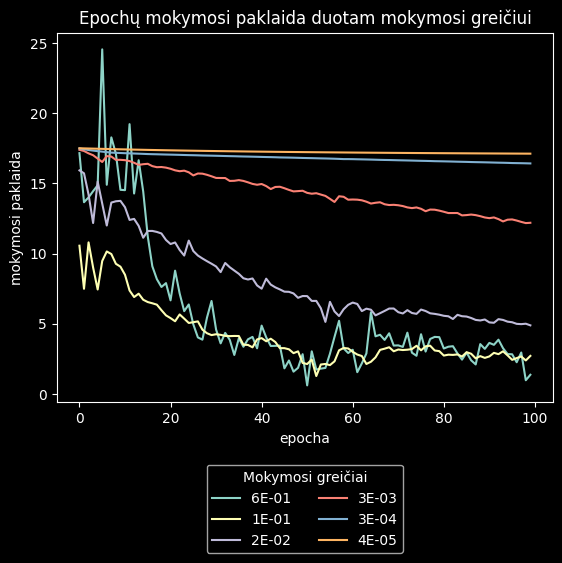

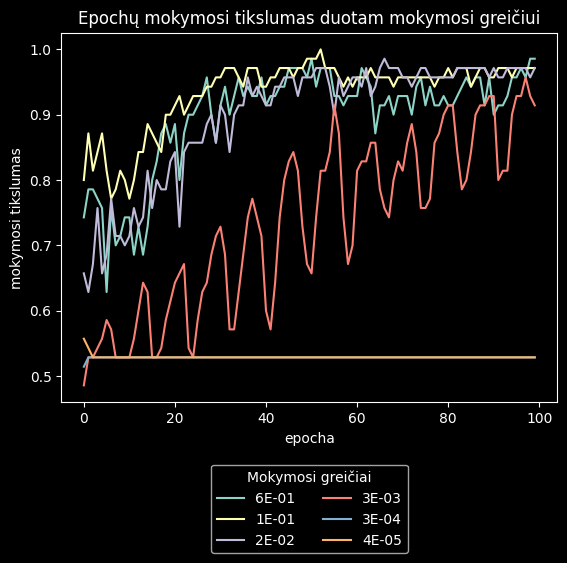

In [ ]:
# @title Using iris dataset

IRIS_FEATURE_COUNT = 4
get_iris_model_results = execute_model_on_data(IRIS_FEATURE_COUNT, IRIS_DATA_PATH, output_filename_prefix='iris_')
get_iris_model_results(
    learning_rates=[i * 0.1**(i - 0.8) for i in range(1, 7)],
    train_epochs=100
    )

Mean error = 0.02, accuracy = 0.99 for learning rate = 0.630957
Mean error = 0.02, accuracy = 0.98 for learning rate = 0.126191
Mean error = 0.02, accuracy = 0.98 for learning rate = 0.018929
Mean error = 0.04, accuracy = 0.97 for learning rate = 0.002524
Mean error = 0.12, accuracy = 0.93 for learning rate = 0.000315
Mean error = 0.21, accuracy = 0.74 for learning rate = 0.000038
%%GUESSES
\begin{longtable}{lrr}
\toprule
 & Spėjimas & Tiesa \\
\midrule
\endfirsthead
\toprule
 & Spėjimas & Tiesa \\
\midrule
\endhead
\midrule
\multicolumn{3}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
0 & 0 & 0 \\
1 & 0 & 0 \\
2 & 0 & 0 \\
3 & 0 & 0 \\
4 & 0 & 0 \\
5 & 0 & 0 \\
6 & 1 & 1 \\
7 & 1 & 1 \\
8 & 0 & 0 \\
9 & 0 & 0 \\
10 & 0 & 0 \\
11 & 1 & 1 \\
12 & 0 & 0 \\
13 & 0 & 0 \\
14 & 1 & 1 \\
15 & 1 & 1 \\
16 & 0 & 0 \\
17 & 0 & 0 \\
18 & 0 & 0 \\
19 & 0 & 0 \\
20 & 0 & 0 \\
21 & 0 & 0 \\
22 & 1 & 1 \\
23 & 0 & 0 \\
24 & 0 & 0 \\
25 & 0 & 0 \\
26 & 0 & 0 \\
27 & 0 & 0 \

(0.9853658536585366,
 0.015236521289736666,
 '-24,722; 1,941; 2,231; 0,317; 0,627; -0,304; 2,261; 0,213; 1,188; 1,117')

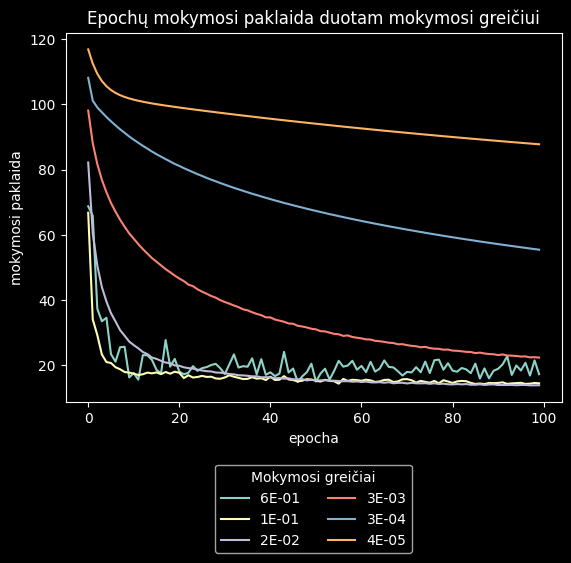

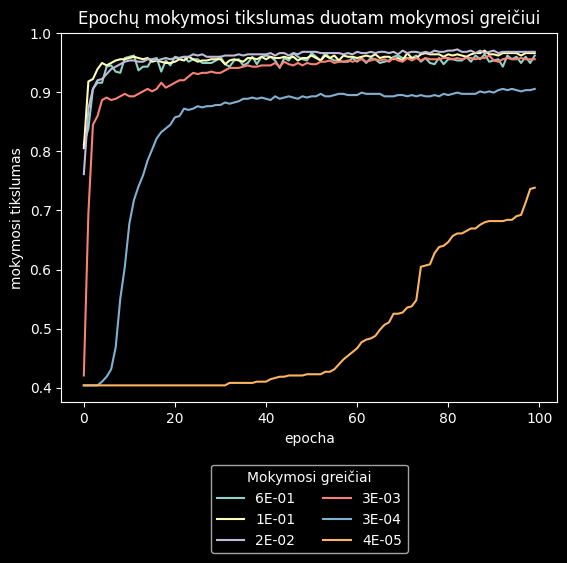

In [ ]:
# @title Using breast cancer dataset

CANCER_FEATURE_COUNT = 9
get_cancer_model_results = execute_model_on_data(CANCER_FEATURE_COUNT, CANCER_DATA_PATH, output_filename_prefix='cancer_')
get_cancer_model_results(
    learning_rates=[i * 0.1**(i - 0.8) for i in range(1, 7)],
    train_epochs=100
    )